# **Prática de Simulação: Métodos da Bisseção e do Ponto Falso**

1) Considere a seguinte função: f(x) = - sinh(x) – 2*x^2 + 5 + e^x, em que sinh(x) é a
função seno hiperbólico. Nós seguiremos a abordagem gráfica, tal como visto
em sala de aula. Desta forma, esboce o gráfico de f(x) dentro de um intervalo
[A B], usando um passo C, ou seja, você deverá calcular e gerar o gráfico da
função f(x) nos pontos x = {A, A+C, A+2C,…,B}. Você deverá testar alguns
valores dos parâmetros A, B e C, e, após os testes, você deve usar os valores
que você achar mais adequados, sem gerar informação redundante.

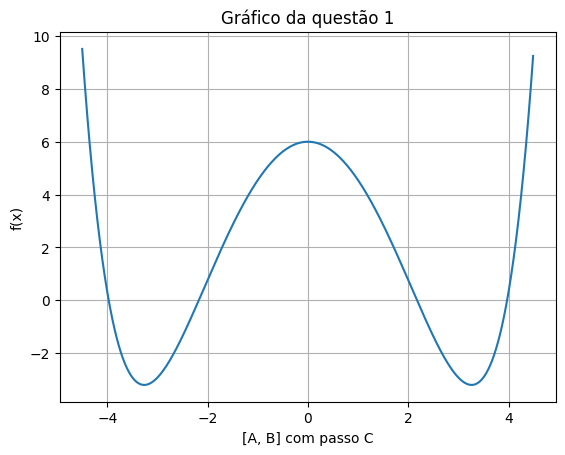

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import math

#Criar a função f(x)
def func(x):

  return -np.sinh(x) -2*x**2 + 5 + np.exp(x)

#Determinar o intervalo [A B] e o passo C
'''
Resposta da questão 2:

Foram testados intervalos de positivos e negativos do formato [-A, +A] até
encontrar o intervalo a partir do qual a função "explode". Escolhemos o
intervalo [-4.5, 4.5] e C = 0.01 para menor granularidade. Quaisquer intervalos
maiores, por exemplo [-5, 5], seriam redundantes, pois nenhuma informação
adicional poderia ser obtida através da visualização do gráfico de f(x).
'''
a = -4.5
b = 4.5
c = 0.01

#Calcular os valores de f(x) nos pontos x = {A, A+C, A+2C, ... , B}
x = np.arange(a, b, c)

#Plotar o gráfico
plt.xlabel("[A, B] com passo C")
plt.ylabel("f(x)")
plt.title("Gráfico da questão 1")
plt.plot(x, func(x))
plt.grid(True)
plt.show()

A intuição é usar os componentes da função para tentar imaginar o seu comportamento. Para tanto, vamos considerar o seguinte:

$f(x) = -sinh(x) -2x² + 5 + e^x$ e $sinh(x) = \frac{(e^x-e^{-x})}{2}$

Dessa forma, a $f(x)$ é dada por

$f(x) = -\frac{(e^x-e^{-x})}{2} -2x² + 5 + e^x$

$f(x) = \frac{e^x}{2} + \frac{e^{-x}}{2} -2x² + 5 $

Note que $\frac{e^x}{2} + \frac{e^{-x}}{2} = cosh(x)$, que cresce mais rápido que $-2x²$. Logo, podemos intuir que

$ \lim_{x\to\infty} f(x) = +\infty$ e $ \lim_{x\to-\infty} f(x) = +\infty$

Portanto, $f(x)$ é uma função que cresce nos extremos e tem um termo $-2x²$ que "puxa para baixo" entre eles. Por isso, foram testados intervalos de positivos e negativos do formato [-A, +A] até encontrar o intervalo a partir do qual a função "explode". Escolhemos o intervalo [-4.5, 4.5] e C = 0.01 para menor granularidade. Quaisquer intervalos maiores, por exemplo [-5, 5], seriam redundantes, pois nenhuma informação adicional poderia ser obtida através da visualização do gráfico de f(x).

2. Explique, em forma de comentário no código, porque você acha que os
parâmetros A, B e C que você escolheu são adequados.

3. Implemente o Método da Bissecção para encontrar uma das raízes da
função f(x). Você deve escolher os limites do intervalo inicial xL e xU que você
achar adequados, de acordo com o resultado da Questão 1. Use como critério
de parada: εa < εS e |f(x)|< εS (simultaneamente). Seu código deve gerar os
seguintes resultados de saída:
- Estimativa da raiz a cada iteração
- Valor de εa a cada iteração
- Valor de |f(x)| a cada iteração
- Número de iterações
- Gráfico com as estimativas da raiz a cada iteração e os respectivos valores de
f(x).

Estimativa da raiz: 2.25
Erro relativo: 0.3333333333333333
Módulo de f(x): 0.32843246953980376
N. de iterações: 1
Estimativa da raiz: 1.875
Erro relativo: 0.2
Módulo de f(x): 1.3058370435875206
N. de iterações: 2
Estimativa da raiz: 2.0625
Erro relativo: 0.09090909090909091
Módulo de f(x): 0.4885600034384643
N. de iterações: 3
Estimativa da raiz: 2.15625
Erro relativo: 0.043478260869565216
Módulo de f(x): 0.07839196858868291
N. de iterações: 4
Estimativa da raiz: 2.203125
Erro relativo: 0.02127659574468085
Módulo de f(x): 0.1256604217657884
N. de iterações: 5
Estimativa da raiz: 2.1796875
Erro relativo: 0.010752688172043012
Módulo de f(x): 0.023765654533725922
N. de iterações: 6
Estimativa da raiz: 2.16796875
Erro relativo: 0.005405405405405406
Módulo de f(x): 0.027283802144257407
N. de iterações: 7
Estimativa da raiz: 2.173828125
Erro relativo: 0.0026954177897574125
Módulo de f(x): 0.001751300609484474
N. de iterações: 8


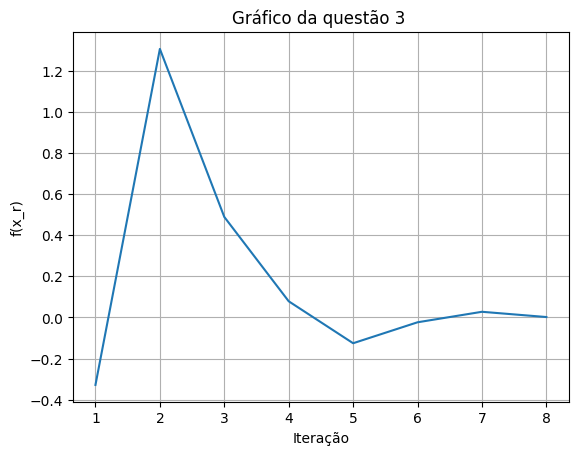

In [59]:
import math

cont = 0
estimativas = []

# algoritmo da bissecção
def bisec(x_l, x_u, f, x_r_velho):
  global cont

  #Estimativa da raiz
  x_r = (x_l + x_u)/2

  #Erro especificado
  e_s = 0.005

  #Erro relativo
  if (x_r_velho != None):
    estimativas.append(x_r)
    e_a = math.fabs((x_r - x_r_velho)/x_r)
    cont += 1
    print(f"Estimativa da raiz: {x_r}\nErro relativo: {e_a}\nMódulo de f(x): {math.fabs(f(x_r))}\nN. de iterações: {cont}")

    #Critérios de parada
    if (math.fabs(f(x_r)) < e_s or e_a < e_s):
      return x_r

  #Cálculos para determinar onde está a raiz
  if (f(x_l)*f(x_r) < 0):
    return bisec(x_l, x_r, f, x_r)


  elif (f(x_l)*f(x_r) > 0):
    return bisec(x_r, x_u, f, x_r)


  elif (f(x_l)*f(x_r) == 0):
    return x_r

'''
Resposta da questão 4

De maneira geral, o que foi observado no algoritmo condiz com o que foi visto na
teoria de sala de aula. Vale pontuar que quanto mais proximo o intervalo está da
raiz da função, mais preciso é o método , por exemplo para (A=3.5, B=4).

A questão pede especificamente "estimativas da raiz a cada iteração e os
respectivos valores de f(x)". Isso é um pouco ambíguo. Pode ser interpretado como:

1. Iteração X f(x_r): mostra como f(x_r) converge para zero a cada iteração
2. x_r X f(x_r): mostra onde os pontos estão na curva da função

Para a observação do comportamento de convergência do método, achei mais interessante
a opção 1, mas fiquei em dúvida a respeito do que estava sendo pedido.
'''


bisec(0, 3, func, None)

plt.plot(range(1, cont+1), func(np.array(estimativas)))
plt.title("Gráfico da questão 3 ")
plt.grid(True)
plt.xlabel("Iteração")
plt.ylabel("f(x_r)")
plt.show()


4. Explique, em forma de comentário no código, se o comportamento dos
resultados de saída da Questão 3 estão de acordo com o que foi estudado em sala de aula.

5. Repita a Questão 3 usando o Método do Ponto Falso.

Estimativa da raiz: 2.50757494798627
Erro relativo: 0.19637500861506707
Módulo de f(x): 1.3975684016087655
N. de iterações: 1
Estimativa da raiz: 2.261362421979405
Erro relativo: 0.10887795941676234
Módulo de f(x): 0.3773386629235773
N. de iterações: 2
Estimativa da raiz: 2.138256158975972
Erro relativo: 0.057573206318923605
Módulo de f(x): 0.15696573222070853
N. de iterações: 3
Estimativa da raiz: 2.1998092904776883
Erro relativo: 0.02798112171275988
Módulo de f(x): 0.11126342938110056
N. de iterações: 4
Estimativa da raiz: 2.16903272472683
Erro relativo: 0.01418907395910041
Módulo de f(x): 0.02264636641745099
N. de iterações: 5
Estimativa da raiz: 2.184421007602259
Erro relativo: 0.007044559094549299
Módulo de f(x): 0.04436762608816558
N. de iterações: 6
Estimativa da raiz: 2.176726866164545
Erro relativo: 0.0035347298539442364
Módulo de f(x): 0.010874406440464668
N. de iterações: 7


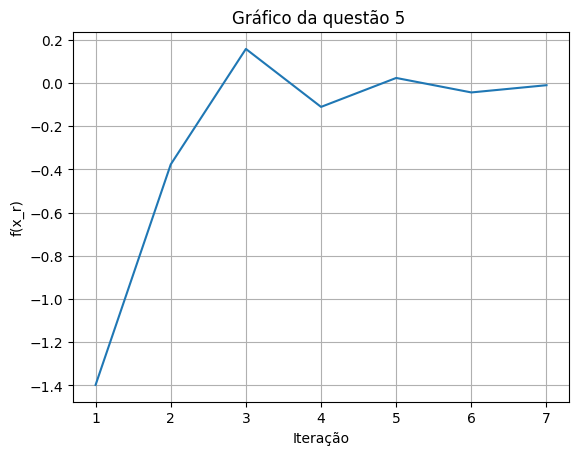

In [60]:

cont = 0
estimativas = []

#Algoritmo do ponto falso
def pontoFalso(x_l, x_u, f, x_r_velho):
  global cont

  #Estimativa da raiz
  x_r = x_u - ((f(x_u)*(x_l-x_u))/(f(x_l)-f(x_u)))

  #Erro especificado
  e_s = 0.005

  #Erro relativo
  if (x_r_velho != None):
    estimativas.append(x_r)
    e_a = math.fabs((x_r - x_r_velho)/x_r)
    cont += 1
    print(f"Estimativa da raiz: {x_r}\nErro relativo: {e_a}\nMódulo de f(x): {math.fabs(f(x_r))}\nN. de iterações: {cont}")

    #Critérios de parada
    if (math.fabs(f(x_r)) < e_s or e_a < e_s):
      return x_r

  #Cálculos para determinar onde está a raiz
  if (f(x_l)*f(x_r) < 0):
    return bisec(x_l, x_r, f, x_r)


  elif (f(x_l)*f(x_r) > 0):
    return bisec(x_r, x_u, f, x_r)


  elif (f(x_l)*f(x_r) == 0):
    return x_r

'''
Resposta da questão 6:

Observamos que o  algoritmo do ponto falso realmente tende a convergir mais
rápido que o algoritmo da bissecção, mas isso depende do comportamento da função
no intervalo. Se os valores de f(x_l) e f(x_u) forem muito assimétricos, o ponto
falso pode ser mais lento em alguns casos.

O gráfico de f(x_r) por iteração apresenta queda mais abrupta do que sua
contrapartida da questão 3.
'''


pontoFalso(0, 3, func, None)

plt.plot(range(1, cont+1), func(np.array(estimativas)))
plt.title("Gráfico da questão 5 ")
plt.grid(True)
plt.xlabel("Iteração")
plt.ylabel("f(x_r)")
plt.show()